# Chest X-Ray Disease Classification - Training on Google Colab GPU

This notebook trains a DenseNet121 model on chest X-ray images using Google Colab's free GPU.

## Steps:
1. Upload your `Dataset` folder to Google Drive
2. Mount Google Drive
3. Run training
4. Download the trained model to use with the local Streamlit app

### Step 1: Check GPU Availability

In [11]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print(f"PyTorch version: {torch.__version__}")

CUDA available: True
GPU: Tesla T4
PyTorch version: 2.10.0+cu128


### Step 2: Mount Google Drive and Set Up Paths

In [12]:
from google.colab import drive
drive.mount('/content/drive')

# Set your paths here
DRIVE_PATH = '/content/drive/MyDrive/Dataset'  # Changed to your Drive folder
DATASET_PATH = DRIVE_PATH  # Your dataset should be here
OUTPUT_PATH = f'{DRIVE_PATH}/models'  # Trained models will be saved here

import os
os.makedirs(OUTPUT_PATH, exist_ok=True)
print(f"Dataset path: {DATASET_PATH}")
print(f"Output path: {OUTPUT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset path: /content/drive/MyDrive/Dataset
Output path: /content/drive/MyDrive/Dataset/models


### Step 3: Install Dependencies

In [14]:
# Most dependencies are pre-installed in Colab, but let's ensure we have everything
!pip install -q torch torchvision

### Step 4: Training Code

In [15]:
import json
import os
import random
from typing import Dict, Tuple, List

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from google.colab import files


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def build_model(num_classes: int) -> torch.nn.Module:
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model


def make_dataloaders(data_dir: str, image_size: int, batch_size: int) -> Tuple[DataLoader, DataLoader, List[str]]:
    train_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(8),
            transforms.ColorJitter(brightness=0.1, contrast=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )
    val_transform = transforms.Compose(
        [
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ]
    )

    train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, train_dataset.classes


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    train_mode: bool,
) -> Dict[str, float]:
    if train_mode:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.set_grad_enabled(train_mode):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

    return {
        "loss": running_loss / max(total, 1),
        "acc": running_correct / max(total, 1),
    }


def save_class_names(path: str, class_names: List[str]) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(class_names, f, indent=2)


# Training Configuration
DATA_DIR = DATASET_PATH
MODEL_DIR = OUTPUT_PATH
IMAGE_SIZE = 224
BATCH_SIZE = 32  # Increased for GPU
EPOCHS = 10
SEED = 42
FREEZE_FEATURES = False  # Set to True to freeze backbone, train only classifier

set_seed(SEED)
os.makedirs(MODEL_DIR, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Verify dataset exists
if not os.path.exists(DATA_DIR):
    print(f"ERROR: Dataset not found at {DATA_DIR}")
    print("Please upload your Dataset folder to Google Drive and update DATASET_PATH")
else:
    print(f"Dataset found at: {DATA_DIR}")

Using device: cuda
Dataset found at: /content/drive/MyDrive/Dataset


### Step 5: Run Training

In [16]:
# Create dataloaders
train_loader, val_loader, class_names = make_dataloaders(DATA_DIR, IMAGE_SIZE, BATCH_SIZE)
print(f"Classes: {class_names}")
print(f"Train samples: {len(train_loader.dataset)}")
print(f"Val samples: {len(val_loader.dataset)}")

# Build model
model = build_model(num_classes=len(class_names)).to(device)
if FREEZE_FEATURES:
    for param in model.features.parameters():
        param.requires_grad = False
    print("Backbone frozen - training classifier only")

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,
    weight_decay=1e-5,
)

# Training loop
best_val_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
model_path = os.path.join(MODEL_DIR, "densenet121_chestxray.pt")
classes_path = os.path.join(MODEL_DIR, "class_names.json")
history_path = os.path.join(MODEL_DIR, "train_history.json")

save_class_names(classes_path, class_names)

for epoch in range(EPOCHS):
    train_metrics = run_epoch(model, train_loader, criterion, optimizer, device, train_mode=True)
    val_metrics = run_epoch(model, val_loader, criterion, optimizer, device, train_mode=False)

    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["acc"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["acc"])

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"train_loss={train_metrics['loss']:.4f} train_acc={train_metrics['acc']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} val_acc={val_metrics['acc']:.4f}"
    )

    if val_metrics["acc"] > best_val_acc:
        best_val_acc = val_metrics["acc"]
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": class_names,
                "image_size": IMAGE_SIZE,
            },
            model_path,
        )
        print(f"Saved best model to: {model_path}")

# Save training history
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print(f"\nTraining complete! Best val_acc={best_val_acc:.4f}")
print(f"Model saved to: {model_path}")
print(f"Class names saved to: {classes_path}")

Classes: ['bacterial_pneumonia', 'covid', 'normal', 'tuberculosis', 'viral_pneumonia']
Train samples: 2500
Val samples: 500
Epoch 1/10 | train_loss=0.6415 train_acc=0.7672 | val_loss=0.2758 val_acc=0.9120
Saved best model to: /content/drive/MyDrive/Dataset/models/densenet121_chestxray.pt
Epoch 2/10 | train_loss=0.2330 train_acc=0.9216 | val_loss=0.2273 val_acc=0.9080
Epoch 3/10 | train_loss=0.1561 train_acc=0.9460 | val_loss=0.1194 val_acc=0.9620
Saved best model to: /content/drive/MyDrive/Dataset/models/densenet121_chestxray.pt
Epoch 4/10 | train_loss=0.0909 train_acc=0.9684 | val_loss=0.1121 val_acc=0.9680
Saved best model to: /content/drive/MyDrive/Dataset/models/densenet121_chestxray.pt
Epoch 5/10 | train_loss=0.0748 train_acc=0.9756 | val_loss=0.1157 val_acc=0.9640
Epoch 6/10 | train_loss=0.0852 train_acc=0.9708 | val_loss=0.4166 val_acc=0.8640
Epoch 7/10 | train_loss=0.0608 train_acc=0.9804 | val_loss=0.1883 val_acc=0.9340
Epoch 8/10 | train_loss=0.0735 train_acc=0.9748 | val_los

### Step 6: Download Trained Model

Run this cell to download the trained model to your local machine. The model will be saved in the `models` folder for use with the Streamlit app.

In [17]:
# Download the trained model files
model_path = os.path.join(MODEL_DIR, "densenet121_chestxray.pt")
classes_path = os.path.join(MODEL_DIR, "class_names.json")
history_path = os.path.join(MODEL_DIR, "train_history.json")

if os.path.exists(model_path):
    print("Downloading trained model...")
    files.download(model_path)
    print("\nDownloading class names...")
    files.download(classes_path)
    print("\nDownloading training history...")
    files.download(history_path)
    print("\nDone! Move these files to the 'models' folder in your project.")
else:
    print("Model not found. Please run training first.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done! Move these files to the 'models' folder in your project.


### Step 7 (Optional): Plot Training History

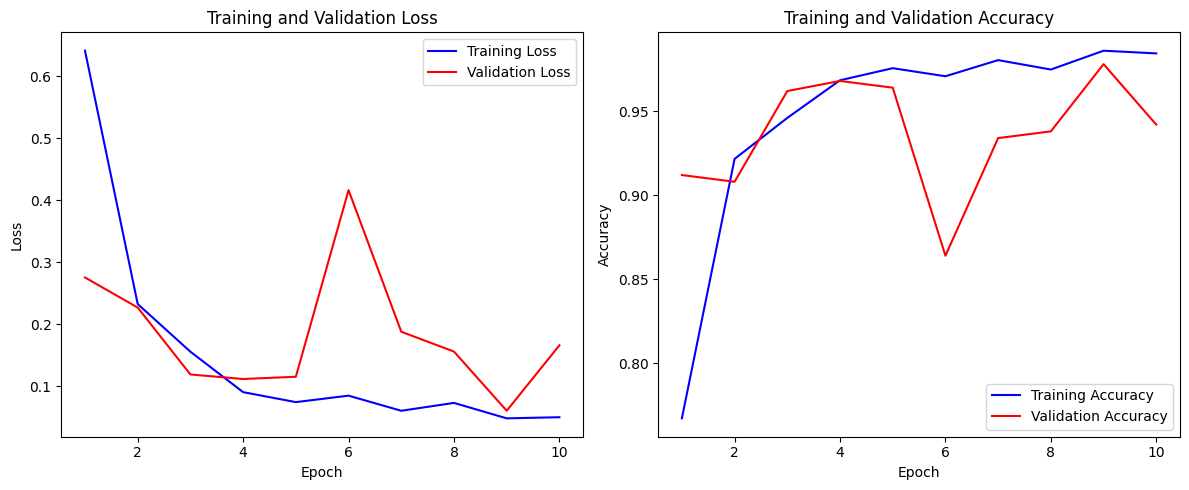

Training history plot saved to: training_history.png


In [18]:
import matplotlib.pyplot as plt

# Plot training history
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], 'b-', label='Training Accuracy')
plt.plot(epochs, history['val_acc'], 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'training_history.png'), dpi=150)
plt.show()

print("Training history plot saved to: training_history.png")